### Python implementation of Leen's Network (minimal)

This notebook is an example of code implementation of Leen's algorithm to find principal components. This notebook focuses on the core algorithm of the Leen's minimal network, which is a simplified version of the full Leen's network. The minimal network is designed to capture the essential features of the algorithm while accurately capturing all the PCs of the input data. 

The math derivations are below:

$$
\mathbf{y} = \mathbf{w} \mathbf{x}
$$

$$
S = (I + q) y
$$

$$
\Delta W_i = \eta_w (\langle x s_i \rangle - \gamma_w \langle y_i^2 \rangle w_i)
$$

$$
\Delta q_{ik} = \eta_q (- \langle y_i^2 + y_k^2 \rangle * q_{ik} - C\langle y_i y_k \rangle), q_{ii} = 0
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from hebbian.models import LeenMinimalPCA, LeenCompletePCA

### Leen's model, complete:

$$
\mathbf{y_{t+1} = W(t) x_t + q(t) y_t}
$$

Forward weights update:
$$
\Delta W = \eta_w (\langle y x^\top \rangle - diag(yy^\top) W)
$$

The lateral connection update, with activity dependent way:

$$
\Delta q_{ik} = \eta_q (\langle y_i^2 + y_k^2 \rangle ) q_{ik} - C(\langle y_i y_k \rangle)
$$




In [2]:
from hebbian.utils import generate_samples, compute_eigen_decomposition, generate_covariance_matrix, Y_aligned_training_testing

### Helper functions:

- PCA alignment helpers
- Data generation helpers
- Training and evaluation helpers


### Practical Example: 3 Neurons test case
Create an input matrix X with information about the eigenvalues and eigenvectors of the covariance matrix of the data.

In [3]:
d = 3
m = 3
number_of_samples = 300000
X = generate_samples(d, number_of_samples)
eigenvalues, eigenvectors = compute_eigen_decomposition(X, center_data=True, return_covariance=False)
print(f"eigenvalues: {eigenvalues}, eigenvectors: {eigenvectors}")

# model = LeenMinimalPCA(d, m, eta_w=2e-3, eta_q=1.5e-1, C=1.8,
#                        ema_alpha=-1.1,
#                        clip_q_spectral=-1.9, seed=None)



eigenvalues: [2.67728192 0.83014864 0.18573415], eigenvectors: [[ 0.10639165 -0.05772784  0.99264712]
 [-0.95730868 -0.27580182  0.0865647 ]
 [-0.26877669  0.95947947  0.08460637]]


In [4]:
# --- Step 1: Define the desired data structure ---
input_dimension = 10
num_principal_components = 3
principal_eigenvalues = [20.0, 2.0, 0.2] # The "strength" of our 3 PCs

# --- Create the full 10D eigenvalue vector ---
# Start with a vector of small noise values
full_eigenvalues = np.full(input_dimension, 1e-5)
# Place your 3 principal eigenvalues at the beginning
full_eigenvalues[0:num_principal_components] = principal_eigenvalues

# --- Call your first function to create the covariance matrix ---
low_rank_cov_matrix = generate_covariance_matrix(
    dim=input_dimension,
    method='eigenvalues',
    eigenvalues=full_eigenvalues,
    seed=42
)

# --- Step 2: Generate the samples ---
num_samples = 100000
mean_vector = np.zeros(input_dimension) # As in your generate_samples function

# --- Use the logic from inside your generate_samples function ---
# This is the core line that creates the data
samples = np.random.multivariate_normal(
    mean=mean_vector,
    cov=low_rank_cov_matrix,  # Use the matrix we created in Step 1
    size=num_samples
)

# --- Also borrow the final centering step from your function ---
samples -= samples.mean(axis=0, keepdims=True)

print(f"\nGenerated data matrix with shape: {samples.shape}")

# --- Verification ---
# Let's prove it worked by checking the eigenvalues of our final data
sample_cov = np.cov(samples, rowvar=False)
recovered_eigenvalues = np.round(np.linalg.eigvalsh(sample_cov),3)

print("\nEigenvalues recovered from the final data (sorted):")
print(np.sort(recovered_eigenvalues)[::-1])



Generated data matrix with shape: (100000, 10)

Eigenvalues recovered from the final data (sorted):
[20.06   2.012  0.201  0.     0.     0.     0.     0.     0.     0.   ]


In [7]:
# 3.1 Complete mode
# model = LeenCompletePCA(d, m, eta_w=1e-5, eta_q=9e-4, C=2.0,
#                        ema_alpha=0.1, symmetrize_q=True, seed=None, settling_steps=10, noise_level=0.01)

# 3.2 Minimal mode
model = LeenMinimalPCA(d, m, eta_w=1e-5, eta_q=9e-4, C=2.0,
                       ema_alpha=0.1, symmetrize_q=True, seed=None)
# training_testing(model, X, number_of_samples, m)
model_paras = {
    'input_dim': d,
    'output_dim': m,
    'eta_w': 1e-5,
    'eta_q': 1e-4,
    'C': 1.0,
    'ema_alpha': 0.1,
    'symmetrize_q': True,
    'seed': None,
    # 'noise_level': 0.01,
    # 'settling_steps': 10,
}
# Y_aligned_training_testing(model, X, batch_size=1, alignment = "corr")
# Y_aligned_training_testing_online(model, X, batch_size=1, alignment = "corr")
# averaged_training_testing_W(LeenCompletePCA, model_paras=model_paras, X=X, runs=10, batch_size=100, graph=True)
# averaged_training_testing_Y(LeenCompletePCA, model_paras=model_paras, X=X, runs=10, batch_size=1, graph=True)


run  1 | order = [0 2 1] | best|corr|= [0.717 0.957 0.657]
run  2 | order = [2 0 1] | best|corr|= [0.813 0.909 0.856]
run  3 | order = [1 2 0] | best|corr|= [0.667 0.697 0.878]
run  4 | order = [1 2 0] | best|corr|= [0.747 0.887 0.691]
run  5 | order = [1 2 0] | best|corr|= [0.958 0.991 0.719]
run  6 | order = [0 1 2] | best|corr|= [0.91  0.668 0.411]
run  7 | order = [0 1 2] | best|corr|= [0.886 0.993 0.427]
run  8 | order = [2 0 1] | best|corr|= [0.862 0.774 0.57 ]
run  9 | order = [1 2 0] | best|corr|= [0.802 0.536 0.906]
run 10 | order = [0 1 2] | best|corr|= [0.43  0.779 0.877]


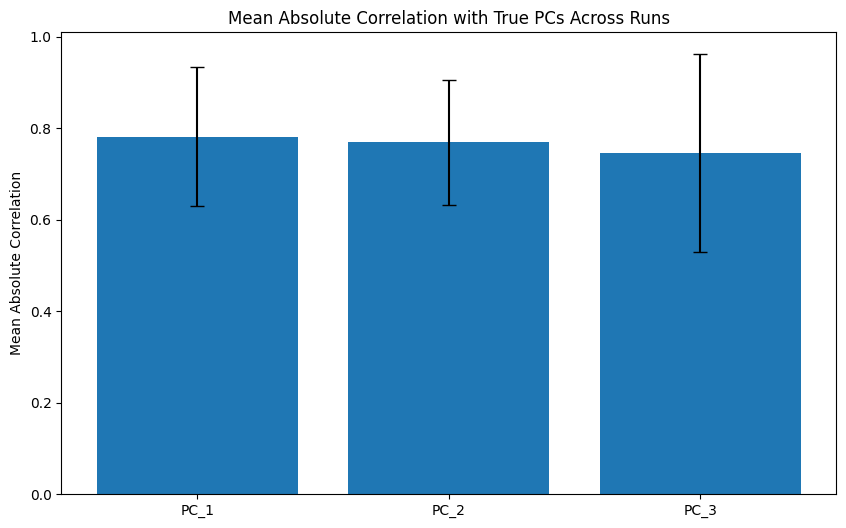

In [12]:
runs = 10

df_best_corr = pd.DataFrame(data=np.full((runs, model_paras['output_dim'] ), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(model_paras['output_dim'])],
                            index=[f"run_{i+1}" for i in range(runs)])
X = samples

for run in range(runs):
    # model = LeenCompletePCA(10, m, eta_w=1e-6, eta_q=1e-2, C=2.0,
    #                    ema_alpha=0.1, symmetrize_q=True, seed=None, settling_steps=10, noise_level=0.01)
    model = LeenMinimalPCA(10, m, eta_w=1e-6, eta_q=1e-2, C=2.0,
                       ema_alpha=0.1, symmetrize_q=True, seed=None)
    order, similarity = Y_aligned_training_testing(model, X, batch_size=1, alignment = "corr")
    # based on the order, sort the similarity to match PC order
    combined_lists = zip(order, similarity)
    # Sort the pairs based on PC_orders
    sorted_combined_lists = sorted(combined_lists)
    # Unzip the sorted pairs
    _, ordered_similarity = zip(*sorted_combined_lists)
    df_best_corr.iloc[run, :] = ordered_similarity
    print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")

# plot the bar graph with error bars of mean and std based on df_best_corr
means = df_best_corr.mean(axis=0)
stds = df_best_corr.std(axis=0)
plt.figure(figsize=(10, 6))
plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
# plt.ylim(0, 1.1)
plt.ylabel('Mean Absolute Correlation')
plt.title('Mean Absolute Correlation with True PCs Across Runs')
plt.show()